# Test Set

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

In [8]:
test_path = "/content/drive/MyDrive/test_set.xlsx"

In [9]:
df_test = pd.read_excel(test_path)

In [10]:
df_test.columns

Index(['ID', 'Comment', 'Stance'], dtype='object')

# Zero-shot stance detection

In [11]:

API_ENDPOINT = "..."
API_KEY = "..."

In [12]:
import openai

In [14]:
client = openai.OpenAI(
    api_key= API_KEY,
    base_url= API_ENDPOINT)

## Model 3.1: Role Context Analyze

In [16]:
input_path = "/content/drive/MyDrive/test_set.xlsx"
output_path = "/content/drive/MyDrive/test_output.xlsx"
checkpoint_interval = 5

In [17]:
import pandas as pd
import openai
import time
import os
from tqdm import tqdm


In [20]:
df = pd.read_excel(output_path if os.path.exists(output_path) else input_path)
print("Resuming from previous checkpoint" if os.path.exists(output_path) else "Starting from input")


current_output_col = "output_3.1"

if current_output_col not in df.columns:
    df[current_output_col] = ""

Starting from input


In [21]:
def task_context_role(comment):
    return f"""
Stance detection is the task of identifying the explicit or implicit position expressed in a text with respect to a specific target.

You are a language model trained to analyze public consultation comments related to the proposed restriction of PFAS substances.

Classify the stance expressed in the following comment toward the PFAS restriction proposal:

Comment:
\"{comment}\"

Possible labels:
- In favor
- Against
- Neutral

Answer with only one of the three labels.
"""

In [23]:
def get_response(prompt):
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": prompt}],
            temperature=0,
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        print(f" Error: {e}")
        return "error"

In [24]:
# MAIN LOOP
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Classifying comments"):
    comment = str(row["Comment"])

    # STANCE CLASSIFICATION
    if not row["output_3.1"]:
        stance = get_response(task_context_role(comment))
        df.at[idx, "output_3.1"] = stance
        print(f"[{idx}] Stance → {stance}")
        time.sleep(1)

    # CHECKPOINT SAVE
    if idx % checkpoint_interval == 0:
        df.to_excel(output_path, index=False)
        print(f"Checkpoint saved at row {idx}")

# FINAL SAVE
df.to_excel(output_path, index=False)
print(" Classification completed and saved.")

Classifying comments:   0%|          | 0/277 [00:00<?, ?it/s]

[0] Stance → Against


Classifying comments:   0%|          | 1/277 [00:02<09:45,  2.12s/it]

Checkpoint saved at row 0
[1] Stance → Against


Classifying comments:   1%|          | 2/277 [00:03<07:43,  1.69s/it]

...

[275] Stance → Neutral


Classifying comments: 100%|█████████▉| 276/277 [06:35<00:01,  1.43s/it]

Checkpoint saved at row 275
[276] Stance → In favor


Classifying comments: 100%|██████████| 277/277 [06:37<00:00,  1.43s/it]

 Classification completed and saved.


# One-shot stance detection

## Model 6: Explicit stance

In [25]:
df = pd.read_excel(output_path if os.path.exists(output_path) else input_path)
print("Resuming from previous checkpoint" if os.path.exists(output_path) else "Starting from input")


current_output_col = "output_6"

if current_output_col not in df.columns:
    df[current_output_col] = ""

Resuming from previous checkpoint


In [26]:
comment_1 = """I support the limitation proposal as it is and hope that it will be adopted as it looks today. PFAS have proven to be toxic and persistent chemicals that negatively affect both human health and the environment, and I therefore only see it as a positive thing that their use is being stopped, especially in products where they are not essential. For example, in makeup, electronics, or in clothes! I believe that it is more beneficial for humanity in the long run if the quality of products potentially decreases slightly (e.g. a raincoat not repelling water as well) than if we become more exposed to higher concentrations of persistent chemicals like PFAS."""
comment_2 = """We acknowledge  the  necessity  of  regulating  PFAS,  but  the  current  restriction proposal is too broad and too impacting to be relevant.  Fluoropolymers (including fluoroelastomers)  should  be  out  of  scope  of  this  restriction,  and  the  “repair  as produced” principle should be respected for all existing vehicles. Fluoropolymers (including fluoroelastomers) were quest their removal from the scope of the restriction. Concerning the manufacturing phase, the risks of PFAS emissions to the environment can be controlled with alternative Risk Management Options. Concerning the use phase, they are considered non- toxic, non-bioaccumulative, non-mobile and as such, are classed as polymers of low concern. Concerning the end-of-life phase, incineration of fluoropolymers does not contribute to environmental PFAS emissions and is a safe method of disposal. 7296       The PFAS REACH restriction is expected to have a major impact on the automotive industry. The automotive industry is a major downstream user of many PFAS, including fluoropolymers, fluorinated gases, and short-chain PFAS. Fluoropolymers are used for several key technical components, such as gaskets, hoses, joints, O-rings, seals, cords, cables, or sleeves. The current proposal does not acknowledge any derogations for such uses, whereas alternatives are not readily available and do not share sufficient properties to be qualified. In the context of this derogation, the automotive industry wishes to express its great concern if the implementation of the restriction were to continue as is and proposes an alternative implementation approach that integrates the technical and economic constraints on the one hand and preserves the objectives of electromobility on the other."""
comment_3 = """The European Society for Medical Oncology (ESMO) notes the draft proposal’s aims to prevent PFAS accumulation in the environment and food chain and welcomes its efforts to improve human health. However, it is pivotal that such action is based on a comprehensive and consistent review of the available evidence as there are growing concerns about the possible impact of the draft proposal on the production, availability and manufacturing of cancer medicines. 9551 Pharmaceuticals, medical devices, excipients, tarting materials and chemical intermediates, reagents, solvents, catalysts, auxiliaries. """

In [27]:
def one_explicit(comment):
    return f"""
Stance detection is the task of identifying the explicit or implicit position expressed in a text with respect to a specific target.

You are a language model trained to analyze public consultation comments related to the proposed restriction of PFAS substances.

Below are examples of previously classified comments:

Example 1:
Comment 1: {comment_1}
Stance 1: In favor

Example 2:
Comment 2: {comment_2}
Stance 2: Against

Example 3:
Comment 3: {comment_3}
Stance 3: Neutral

Taking the examples into consideration, classify the stance expressed in the following comment toward the PFAS restriction proposal:

Comment:
\"{comment}\"

Possible labels:
- In favor
- Against
- Neutral

Answer with only one of the three labels.
"""

In [28]:
# MAIN LOOP
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Classifying comments"):
    comment = str(row["Comment"])

    # STANCE CLASSIFICATION
    if not row["output_6"]:
        stance = get_response(one_explicit(comment))
        df.at[idx, "output_6"] = stance
        print(f"[{idx}] Stance → {stance}")
        time.sleep(1)

    # CHECKPOINT SAVE
    if idx % checkpoint_interval == 0:
        df.to_excel(output_path, index=False)
        print(f"Checkpoint saved at row {idx}")

# FINAL SAVE
df.to_excel(output_path, index=False)
print(" Classification completed and saved.")

Classifying comments:   0%|          | 0/277 [00:00<?, ?it/s]

[0] Stance → Against


Classifying comments:   0%|          | 1/277 [00:02<09:52,  2.15s/it]

Checkpoint saved at row 0
[1] Stance → Against


Classifying comments:   1%|          | 2/277 [00:03<07:40,  1.68s/it]

...

[275] Stance → Neutral


Classifying comments: 100%|█████████▉| 276/277 [06:37<00:01,  1.49s/it]

Checkpoint saved at row 275
[276] Stance → In favor


Classifying comments: 100%|██████████| 277/277 [06:38<00:00,  1.44s/it]

 Classification completed and saved.


## Model 8: CoT Explanation

In [29]:
df = pd.read_excel(output_path if os.path.exists(output_path) else input_path)
print("Resuming from previous checkpoint" if os.path.exists(output_path) else "Starting from input")


current_output_col = "output_8"
cot_raw_col = "one_cot"

# Ensure both columns exist
for col in [current_output_col, cot_raw_col]:
    if col not in df.columns:
        df[col] = ""

Resuming from previous checkpoint


In [30]:
comment_1 = """As a medical doctor with a special interest in human fluid balance, the importance of the availability of clean drinking water for human beings  is obvious to me. No degree of economic benefit should be allowed to endanger this availability of clean water."""
comment_2 = """MicrotracBEL supports the two statements made by FCJ and JFIA on the issues of proposed restriction, as per attached in section IV. 9269 PTFE thread sealing tape, semicondactors as compornents, other uses of FKM, PTFE and PCTFE as sealing materials for high vacuum. End use is in analytical instruments for powder and particle characterisation. 9269     a. FKM, PTFE, PCTFE. Components for semiconductors using FKM and PCTFE are also used, giving problems to the supply of this component. The anual tonnage and emissions No annual tonnage and emissions information is available. b. Used as tubing, sealing material and gaskets for high vacuum applications. Heat resistant, corrosion resistant, low moisture absorption and flexible. c. Our company produces analytical instruments for characterising powder and granular materials. These instruments are used in a wide range of industries, including catalysts, batteries, pharmaceuticals, and electronic materials for research and quality control purposes. There are no specific figures, but many companies use analytical instruments for powder analysis. d. There are no effective alternatives that can guarantee equivalent performance. e.f. No alternative candidates are available. g. No information is available."""
comment_3 = """We would like to provide specific information on the use of PFAS in the chemical industry (chemicals synthesis). See two attached documents (one non-confidential version and one confidential version)."""

In [31]:
explanation_1 = """The commenter emphasizes the need for clean drinking water from a medical perspective. In particular, they highlight that economic interests should not be prioritized over human health. While PFAS are not explicitly mentioned, their negative effects on human health due to contamination of drinking water are well known. For this reason, the commenter appears to support the restriction of PFAS use, aligning with the goals of the PFAS policy proposal."""
explanation_2 = """The commenter expresses support for the statements made by FCJ and JFIA which find the proposed PFAS restriction excessive and that affirm that fluoropolymers should be exempted from it. The commenter also provides context on the use of PFAS-related substances such as FKM, PTFE and PCTFE. Their usage is essential for vacuum sealing, tubing, and gaskets in equipment used across several sectors such as pharmaceuticals and electronics. The commenters highlight the absence of alternatives with equivalent performance. It also states that information about annual tonnage and emissions are not available. For these reasons the commenter appears to oppose the PFAS restriction policy."""
explanation_3 = """The commenter indicates their intent to provide detailed information on the use of PFAS in the chemical industry, specifically in the chemicals synthesis. However, the relevant content is shared in two attachments of which one is confidential. Without access to the attachments it is hard to classify the comment position toward the PFAS restriction. For this reason the comment appears to be neutral with respect to the policy."""

In [32]:
def one_shot_cot_explanation(comment):
    return f"""
Stance detection is the task of identifying the explicit or implicit position expressed in a text with respect to a specific target.

You are a language model trained to analyze public consultation comments related to the proposed restriction of PFAS substances.

Below are examples of previously classified comments:

Example 1:
Comment 1: {comment_1}
Explanation 1: {explanation_1}
Stance 1: In favor

Example 2:
Comment 2: {comment_2}
Explanation 2: {explanation_2}
Stance 2: Against

Example 3:
Comment 3: {comment_3}
Explanantion 3: {explanation_3}
Stance 3: Neutral

Now think step-by-step and explain the stance (in favor, against, or neutral) of the comment toward the PFAS restriction policy.

Comment:
\"{comment}\"

Explanation:
"""


In [34]:
def one_shot_cot_answer(comment, explanation):
    return f"""
Given your explanation: {explanation}

Determine the final stance expressed in the following comment toward the PFAS restriction proposal:

Comment:
\"{comment}\"

Possible labels:
- In favor
- Against
- Neutral

Answer with only one of the three labels.
"""


In [35]:
# MAIN LOOP
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Classifying comments"):
    comment = str(row["Comment"])

    # STEP 1: Generate explanation (one_cot)
    if not row[cot_raw_col]:
        explanation = get_response(one_shot_cot_explanation(comment))
        df.at[idx, cot_raw_col] = explanation
        print(f"[{idx}]  Explanation → {explanation}")
        time.sleep(1)
    else:
        explanation = row[cot_raw_col]

    # STEP 2: Final stance prediction (output_8)
    if not row[current_output_col]:
        stance = get_response(one_shot_cot_answer(comment, explanation))
        df.at[idx, current_output_col] = stance
        print(f"[{idx}]  Stance → {stance}")
        time.sleep(1)

    # CHECKPOINT SAVE
    if idx % checkpoint_interval == 0:
        df.to_excel(output_path, index=False)
        print(f" Checkpoint saved at row {idx}")

# FINAL SAVE
df.to_excel(output_path, index=False)
print(" Classification completed and saved.")

Classifying comments:   0%|          | 0/277 [00:00<?, ?it/s]

[0]  Stance → Against


Classifying comments:   0%|          | 1/277 [00:02<09:59,  2.17s/it]

 Checkpoint saved at row 0
[1]  Explanation → The commenter discusses the critical role of PTFE tubing in semiconductor applications, emphasizing its unique properties such as chemical resistance and its necessity for delivering harsh chemicals like hydrogen fluoride and hydrogen peroxide. They argue that these chemicals are essential for the purification of semiconductor processor chips, which are vital for the production of microprocessors. The commenter highlights that without PTFE tubing, the economical and efficient production of microprocessors would be jeopardized, potentially leading to job losses in the semiconductor industry.

The mention of ongoing studies related to incineration and recycling projects indicates that the commenter is aware of environmental concerns and is engaged in finding solutions. However, the primary focus of the comment is on the importance of PTFE tubing for maintaining production efficiency and job security in the semiconductor sector.

Given this co

Classifying comments:   1%|          | 2/277 [00:06<14:28,  3.16s/it]

...

[275]  Explanation → The comment discusses the broader context of chemical governance, emphasizing the importance of access to chemical reference standards for effective risk assessment and regulation. It highlights the challenges posed by the limited availability of reference standards for PFAS, which undermines the ability to produce independent scientific evidence necessary for effective chemical risk governance. The commenter suggests several potential improvements to the current system, including the creation of a reference standards repository and reconsidering regulatory approaches for PFAS in the absence of adequate standards.

While the comment does not explicitly state a position for or against the restriction of PFAS, it raises critical questions about the current governance framework and the need for better tools and standards to manage chemical risks, including those posed by PFAS. The focus on improving governance and the mention of regulating PFAS suggest a concern for p

Classifying comments: 100%|█████████▉| 276/277 [19:47<00:04,  4.40s/it]

 Checkpoint saved at row 275
[276]  Explanation → The comment from the province of Gelderland clearly expresses a strong position in favor of a rapid and total ban on PFAS substances. The commenter outlines several key reasons for this stance:

1. **Health and Environmental Protection**: The province emphasizes the need to protect the health of its inhabitants and the environment from the harmful effects of PFAS, which are described as "forever chemicals" that do not degrade and can cause significant contamination of soil, air, and water.

2. **Comprehensive Approach**: The comment supports the idea that the restriction proposal should target the entire group of PFAS to avoid the substitution of one harmful substance for another. This indicates a commitment to a thorough and effective ban rather than a partial or ineffective measure.

3. **Urgency of Action**: The province argues against postponing the ban, highlighting the increasing pressure on environmental quality and the urgency o

Classifying comments: 100%|██████████| 277/277 [19:53<00:00,  4.31s/it]

 Classification completed and saved.


# Few-shot stance detection

## Model 9: Grouped stances

In [36]:
df = pd.read_excel(output_path if os.path.exists(output_path) else input_path)
print("Resuming from previous checkpoint" if os.path.exists(output_path) else "Starting from input")


current_output_col = "output_9"

if current_output_col not in df.columns:
    df[current_output_col] = ""

Resuming from previous checkpoint


In [37]:
comment_1 = """I support the limitation proposal as it is and hope that it will be adopted as it looks today. PFAS have proven to be toxic and persistent chemicals that negatively affect both human health and the environment, and I therefore only see it as a positive thing that their use is being stopped, especially in products where they are not essential. For example, in makeup, electronics, or in clothes! I believe that it is more beneficial for humanity in the long run if the quality of products potentially decreases slightly (e.g. a raincoat not repelling water as well) than if we become more exposed to higher concentrations of persistent chemicals like PFAS."""
comment_2 = """As a medical doctor with a special interest in human fluid balance, the importance of the availability of clean drinking water for human beings  is obvious to me. No degree of economic benefit should be allowed to endanger this availability of clean water."""
comment_3 = """Over the last years, perfluorocarbons and perfluoropolyethers have been frequently used as dielectric fluids for immersion cooling applications. The use of such liquids entails a high environmental impact as well as severe health risks during operation, maintenance and handling of the immersed equipment. Recently, new and more sustainable dielectric liquids – able to efficiently operate these systems - have entered the market, resulting in no need for per- and polyfluoroalkyl substances anymore. 9165 Cleaning and heat transfer: engineered fluids. Electronics: heat transfer fluid for (single-phase) immersion cooling (in EV, IT equipment). 9165       PFAS alternatives for (single-phase) immersion cooling applications. Recently, sustainable hydrocarbon (e.g. DC COOLING BioLife 4 from TotalEnergies) and ester (e.g. NatureCool2000 from Cargill, Mivolt DF7 from M&I Materials) based dielectric liquids have entered the immersion cooling market."""

comment_4 = """We acknowledge  the  necessity  of  regulating  PFAS,  but  the  current  restriction proposal is too broad and too impacting to be relevant.  Fluoropolymers (including fluoroelastomers)  should  be  out  of  scope  of  this  restriction,  and  the  “repair  as produced” principle should be respected for all existing vehicles. Fluoropolymers (including fluoroelastomers) were quest their removal from the scope of the restriction. Concerning the manufacturing phase, the risks of PFAS emissions to the environment can be controlled with alternative Risk Management Options. Concerning the use phase, they are considered non- toxic, non-bioaccumulative, non-mobile and as such, are classed as polymers of low concern. Concerning the end-of-life phase, incineration of fluoropolymers does not contribute to environmental PFAS emissions and is a safe method of disposal. 7296       The PFAS REACH restriction is expected to have a major impact on the automotive industry. The automotive industry is a major downstream user of many PFAS, including fluoropolymers, fluorinated gases, and short-chain PFAS. Fluoropolymers are used for several key technical components, such as gaskets, hoses, joints, O-rings, seals, cords, cables, or sleeves. The current proposal does not acknowledge any derogations for such uses, whereas alternatives are not readily available and do not share sufficient properties to be qualified. In the context of this derogation, the automotive industry wishes to express its great concern if the implementation of the restriction were to continue as is and proposes an alternative implementation approach that integrates the technical and economic constraints on the one hand and preserves the objectives of electromobility on the other."""
comment_5 = """MicrotracBEL supports the two statements made by FCJ and JFIA on the issues of proposed restriction, as per attached in section IV. 9269 PTFE thread sealing tape, semicondactors as compornents, other uses of FKM, PTFE and PCTFE as sealing materials for high vacuum. End use is in analytical instruments for powder and particle characterisation. 9269     a. FKM, PTFE, PCTFE. Components for semiconductors using FKM and PCTFE are also used, giving problems to the supply of this component. The anual tonnage and emissions No annual tonnage and emissions information is available. b. Used as tubing, sealing material and gaskets for high vacuum applications. Heat resistant, corrosion resistant, low moisture absorption and flexible. c. Our company produces analytical instruments for characterising powder and granular materials. These instruments are used in a wide range of industries, including catalysts, batteries, pharmaceuticals, and electronic materials for research and quality control purposes. There are no specific figures, but many companies use analytical instruments for powder analysis. d. There are no effective alternatives that can guarantee equivalent performance. e.f. No alternative candidates are available. g. No information is available."""
comment_6 = """As engineering service provider, planner and constructor for large-scale plant construction, we specify and handle various materials and material groups. Among others, the following semi-finished products and assemblies made of fluoropolymers are used in our range of activities: - Fluoropolymers as sealing materials (flat, O-ring, mechanical seal, etc.) in various equipment/pipelines - Fluoropolymers as lining materials in pumps and pipeline materials - Fluoropolymers as membrane materials in pumps, electrolyzers Additionally, fluoropolymers are indirectly used as coolants or additives in associated processes, which however fall within the scope of the end user/customer. As the broad field of mechanical and plant engineering is not listed in the sectors mentioned in Annex XV (Table 9) of the restriction report, the following areas were selected as the most relevant - Energy sector (Annex E.2.12.) - Sector as a whole - Petroleum and mining (Annex E.2.15.) - Fluoropolymer applications Furthermore, see SECTION III. Non-confidential comments. 9567" "We, as large-scale plant builders, can divide the percentage emission shares for our scope as follows: 0% emissions in the production phase (as we appear as end users) 0% emissions in the usage phase 100% emissions in the end-of-life phase (this is outside our scope and not considered) 9567"    "See SECTION III. Non-confidential comments"""

comment_7 = """The European Society for Medical Oncology (ESMO) notes the draft proposal’s aims to prevent PFAS accumulation in the environment and food chain and welcomes its efforts to improve human health. However, it is pivotal that such action is based on a comprehensive and consistent review of the available evidence as there are growing concerns about the possible impact of the draft proposal on the production, availability and manufacturing of cancer medicines. 9551 Pharmaceuticals, medical devices, excipients, tarting materials and chemical intermediates, reagents, solvents, catalysts, auxiliaries. """
comment_8 = """We would like to provide specific information on the use of PFAS in the chemical industry (chemicals synthesis). See two attached documents (one non-confidential version and one confidential version)."""
comment_9 = """Integrated DNA Technologies, a Biotechnology company, develops, manufactures, and markets nucleic acid (DNA and RNA) products that support the life sciences industry. IDT supplies synthetic biology products used in genomics research, diagnostics, specialized reagents, consumables, and medical device products. Our customers use our products in applications ranging from fundamental biological and genomics research to making lifesaving vaccines, biologic drugs, and novel cell and gene therapies. We supply the tools and services that help our customers do their work better, faster, and safer. IDT designs, builds, and then deploys proprietary manufacturing equipment into the European Union to manufacture nucleic acid products. We have over 1400 associates across nine countries worldwide including manufacturing sites in Belgium, Singapore, and the USA.  General Comments According to ECHA’s Press Release, the purpose of the consultation is to give anyone with information on PFAS the opportunity to have their say. Of particular interest is information relevant to the risks, socio-economic aspects, and alternative substances. ECHA’s scientific committees for Risk Assessment (RAC) and for Socio-Economic Analysis (SEAC) will use the consultation input to evaluate the proposed restriction and to form an opinion on it.  However, due to the rather high volume of the information that must be collected and analysed with regard to the economic and health impacts of the proposed restriction, we request a 6-month extension to the consultation period, in order to gather detailed data on these points."""

In [38]:
def few_grouped(comment):
    return f"""
Stance detection is the task of identifying the explicit or implicit position expressed in a text with respect to a specific target.

You are a language model trained to analyze public consultation comments related to the proposed restriction of PFAS substances.

Below are examples of previously classified comments:


Example 1:
Comment 1: {comment_1}
Stance 1: In favor

Example 2:
Comment 2: {comment_2}
Stance 2: In favor

Example 3:
Comment 3: {comment_3}
Stance 3: In favor

Example 4:
Comment 4: {comment_4}
Stance 4: Against

Example 5:
Comment 5: {comment_5}
Stance 5: Against

Example 6
Comment 6: {comment_6}
Stance 6: Against

Example 7:
Comment 7: {comment_7}
Stance 7: Neutral

Example 8:
Comment 8: {comment_8}
Stance 8: Neutral

Example 9:
Comment 9: {comment_9}
Stance 9: Neutral

Taking the examples into consideration, classify the stance expressed in the following comment toward the PFAS restriction proposal:


Comment:
\"{comment}\"

Possible labels:
- In favor
- Against
- Neutral

Answer with only one of the three labels.
"""

In [39]:
# MAIN LOOP
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Classifying comments"):
    comment = str(row["Comment"])

    # STANCE CLASSIFICATION
    if not row["output_9"]:
        stance = get_response(few_grouped(comment))
        df.at[idx, "output_9"] = stance
        print(f"[{idx}] Stance → {stance}")
        time.sleep(1)

    # CHECKPOINT SAVE
    if idx % checkpoint_interval == 0:
        df.to_excel(output_path, index=False)
        print(f"Checkpoint saved at row {idx}")

# FINAL SAVE
df.to_excel(output_path, index=False)
print(" Classification completed and saved.")

Classifying comments:   0%|          | 0/277 [00:00<?, ?it/s]

[0] Stance → Against


Classifying comments:   0%|          | 1/277 [00:01<07:08,  1.55s/it]

Checkpoint saved at row 0
[1] Stance → Against


Classifying comments:   1%|          | 2/277 [00:02<06:39,  1.45s/it]

...

[275] Stance → Neutral


Classifying comments: 100%|█████████▉| 276/277 [06:48<00:01,  1.57s/it]

Checkpoint saved at row 275
[276] Stance → In favor


Classifying comments: 100%|██████████| 277/277 [06:50<00:00,  1.48s/it]

 Classification completed and saved.


## Model 11.1 : More In favor

In [40]:
df = pd.read_excel(output_path if os.path.exists(output_path) else input_path)
print("Resuming from previous checkpoint" if os.path.exists(output_path) else "Starting from input")


current_output_col = "output_11.1"

if current_output_col not in df.columns:
    df[current_output_col] = ""

Resuming from previous checkpoint


In [41]:
comment_1 = """I support the limitation proposal as it is and hope that it will be adopted as it looks today. PFAS have proven to be toxic and persistent chemicals that negatively affect both human health and the environment, and I therefore only see it as a positive thing that their use is being stopped, especially in products where they are not essential. For example, in makeup, electronics, or in clothes! I believe that it is more beneficial for humanity in the long run if the quality of products potentially decreases slightly (e.g. a raincoat not repelling water as well) than if we become more exposed to higher concentrations of persistent chemicals like PFAS."""
comment_2 = """As a medical doctor with a special interest in human fluid balance, the importance of the availability of clean drinking water for human beings  is obvious to me. No degree of economic benefit should be allowed to endanger this availability of clean water."""
comment_3 = """Over the last years, perfluorocarbons and perfluoropolyethers have been frequently used as dielectric fluids for immersion cooling applications. The use of such liquids entails a high environmental impact as well as severe health risks during operation, maintenance and handling of the immersed equipment. Recently, new and more sustainable dielectric liquids – able to efficiently operate these systems - have entered the market, resulting in no need for per- and polyfluoroalkyl substances anymore. 9165 Cleaning and heat transfer: engineered fluids. Electronics: heat transfer fluid for (single-phase) immersion cooling (in EV, IT equipment). 9165       PFAS alternatives for (single-phase) immersion cooling applications. Recently, sustainable hydrocarbon (e.g. DC COOLING BioLife 4 from TotalEnergies) and ester (e.g. NatureCool2000 from Cargill, Mivolt DF7 from M&I Materials) based dielectric liquids have entered the immersion cooling market."""
comment_4 = """I think it is incredibly important that PFAS disappears and that the restriction proposal is therefore adopted without being watered down. As a citizen and consumer within the EU, one should be able to trust that the goods one purchases are free from carcinogenic and hormone-disrupting chemicals. As a citizen, I want to be able to trust that the EU has my health in focus, and adopting the restriction proposal would signal this. I am prepared for goods to have deteriorated properties as a result of PFAS disappearing, but I believe that the positive effects of discontinuing the use of PFAS are much greater than the negatives."""
comment_5 = """As part of the ZeroPM project ( Stockholm University is building a database of alternatives to persistent, mobile and toxic (PMT) substances, and to per- and polyfluoroalkyl substances (PFAS). We have attached a short report which presents the general structure of the database and the method we have followed to build it.  The beta-version of this database will be publicly available on the ZeroPM website ( ) from the 30th of September 2023, and will be continuously updated as we get more information.  We hope that this resource will support the development of the restriction on uses of PFAS, by providing an information repository of where researchers, innovators and business can consider alternatives to PFAS before the restriction targets. 9280       The aim of the database is to identify the functions provided by PFAS in their different uses and potential alternatives capable of providing similar functions.  We provide a summary of the number of functions provided by PFAS and the number of potential alternatives we have identified for each application in attached document. When relevant, we also provide a list of alternatives which we have identified but were not included in the restriction, to the best of our knowledge. For now, we have identified 520 alternatives to PFAS across all use categories evaluated (but excluding alternatives to PFAS used as active substance and as ingredients in cosmetic products). The database will be updated in the future. Among other, we aim to deepen the search of alternatives for specific use cases of PFAS in order to identify more potential alternatives."""

comment_6 = """MicrotracBEL supports the two statements made by FCJ and JFIA on the issues of proposed restriction, as per attached in section IV. 9269 PTFE thread sealing tape, semicondactors as compornents, other uses of FKM, PTFE and PCTFE as sealing materials for high vacuum. End use is in analytical instruments for powder and particle characterisation. 9269     a. FKM, PTFE, PCTFE. Components for semiconductors using FKM and PCTFE are also used, giving problems to the supply of this component. The anual tonnage and emissions No annual tonnage and emissions information is available. b. Used as tubing, sealing material and gaskets for high vacuum applications. Heat resistant, corrosion resistant, low moisture absorption and flexible. c. Our company produces analytical instruments for characterising powder and granular materials. These instruments are used in a wide range of industries, including catalysts, batteries, pharmaceuticals, and electronic materials for research and quality control purposes. There are no specific figures, but many companies use analytical instruments for powder analysis. d. There are no effective alternatives that can guarantee equivalent performance. e.f. No alternative candidates are available. g. No information is available."""
comment_7 = """As engineering service provider, planner and constructor for large-scale plant construction, we specify and handle various materials and material groups. Among others, the following semi-finished products and assemblies made of fluoropolymers are used in our range of activities: - Fluoropolymers as sealing materials (flat, O-ring, mechanical seal, etc.) in various equipment/pipelines - Fluoropolymers as lining materials in pumps and pipeline materials - Fluoropolymers as membrane materials in pumps, electrolyzers Additionally, fluoropolymers are indirectly used as coolants or additives in associated processes, which however fall within the scope of the end user/customer. As the broad field of mechanical and plant engineering is not listed in the sectors mentioned in Annex XV (Table 9) of the restriction report, the following areas were selected as the most relevant - Energy sector (Annex E.2.12.) - Sector as a whole - Petroleum and mining (Annex E.2.15.) - Fluoropolymer applications Furthermore, see SECTION III. Non-confidential comments. 9567" "We, as large-scale plant builders, can divide the percentage emission shares for our scope as follows: 0% emissions in the production phase (as we appear as end users) 0% emissions in the usage phase 100% emissions in the end-of-life phase (this is outside our scope and not considered) 9567"    "See SECTION III. Non-confidential comments"""

comment_8 = """The European Society for Medical Oncology (ESMO) notes the draft proposal’s aims to prevent PFAS accumulation in the environment and food chain and welcomes its efforts to improve human health. However, it is pivotal that such action is based on a comprehensive and consistent review of the available evidence as there are growing concerns about the possible impact of the draft proposal on the production, availability and manufacturing of cancer medicines. 9551 Pharmaceuticals, medical devices, excipients, tarting materials and chemical intermediates, reagents, solvents, catalysts, auxiliaries. """
comment_9 = """We would like to provide specific information on the use of PFAS in the chemical industry (chemicals synthesis). See two attached documents (one non-confidential version and one confidential version)."""


In [42]:
def few_imbalance_infavor(comment):
    return f"""
Stance detection is the task of identifying the explicit or implicit position expressed in a text with respect to a specific target.

You are a language model trained to analyze public consultation comments related to the proposed restriction of PFAS substances.

Below are examples of previously classified comments:

Example 1:
Comment 1: {comment_1}
Stance 1: In favor

Example 2:
Comment 2: {comment_2}
Stance 2: In favor

Example 3:
Comment 3: {comment_3}
Stance 3: In favor

Example 4:
Comment 4: {comment_4}
Stance 4: In favor

Example 5:
Comment 5: {comment_5}
Stance 5: In favor

Example 6
Comment 6: {comment_6}
Stance 6: Against

Example 7:
Comment 7: {comment_7}
Stance 7: Against

Example 8:
Comment 8: {comment_8}
Stance 8: Neutral

Example 9:
Comment 9: {comment_9}
Stance 9: Neutral

Taking the examples into consideration, classify the stance expressed in the following comment toward the PFAS restriction proposal:

Comment:
\"{comment}\"

Possible labels:
- In favor
- Against
- Neutral

Answer with only one of the three labels.
"""

In [43]:
# MAIN LOOP
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Classifying comments"):
    comment = str(row["Comment"])

    # STANCE CLASSIFICATION
    if not row["output_11.1"]:
        stance = get_response(few_imbalance_infavor(comment))
        df.at[idx, "output_11.1"] = stance
        print(f"[{idx}] Stance → {stance}")
        time.sleep(1)

    # CHECKPOINT SAVE
    if idx % checkpoint_interval == 0:
        df.to_excel(output_path, index=False)
        print(f"Checkpoint saved at row {idx}")

# FINAL SAVE
df.to_excel(output_path, index=False)
print(" Classification completed and saved.")

Classifying comments:   0%|          | 0/277 [00:00<?, ?it/s]

[0] Stance → Against


Classifying comments:   0%|          | 1/277 [00:01<07:13,  1.57s/it]

Checkpoint saved at row 0
[1] Stance → Against


Classifying comments:   1%|          | 2/277 [00:03<07:25,  1.62s/it]

...

[275] Stance → Neutral


Classifying comments: 100%|█████████▉| 276/277 [06:51<00:01,  1.50s/it]

Checkpoint saved at row 275
[276] Stance → In favor


Classifying comments: 100%|██████████| 277/277 [06:53<00:00,  1.49s/it]


 Classification completed and saved.


# Evaluation

In [44]:
output_path = "/content/drive/MyDrive/test_output.xlsx"

In [45]:
df = pd.read_excel(output_path)

## Results file

In [52]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import os
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')


results_path = "/content/drive/MyDrive/test_results.xlsx"



y_true = df["Stance"]


model_outputs = [
    "output_3.1",  "output_6", "output_8", "output_9",
     "output_11.1"
]


if os.path.exists(results_path):
    results_df = pd.read_excel(results_path, index_col=0)
else:
    results_df = pd.DataFrame()


for model_name in model_outputs:
    if model_name not in df.columns:
        print(f" Skipping {model_name} (not found in dataset)")
        continue

    y_pred = df[model_name]


    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    _, _, f1_class, _ = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0, labels=["In favor", "Against", "Neutral"]
    )


    metrics = pd.Series({
        "Accuracy": accuracy,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1-score": f1_macro,
        "F1 In favor": f1_class[0],
        "F1 Against": f1_class[1],
        "F1 Neutral": f1_class[2],
    }, name=f"model_{model_name.split('_')[1]}")


    results_df[metrics.name] = metrics


results_df.to_excel(results_path)
print(f" All model results saved to {results_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 All model results saved to /content/drive/MyDrive/test_results.xlsx


## Confusion Matrix and Error Analysis

In [1]:
!pip install seaborn

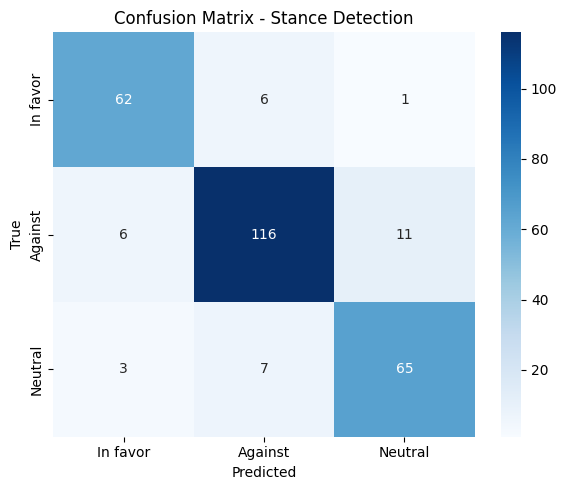

In [5]:


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 3. Load your test file from Google Drive (adjust path as needed)
file_path = "/content/drive/MyDrive/test_output.xlsx"
df = pd.read_excel(file_path)

# 4. Clean up column values
df["Stance"] = df["Stance"].astype(str).str.strip()
df["output_9"] = df["output_9"].astype(str).str.strip()

# 5. Label each row as correct or misclassified
def label_stance_error(row):
    if row["Stance"] == row["output_9"]:
        return "Correct"
    else:
        return f'{row["Stance"]} → {row["output_9"]}'

df["stance_confusion_label_9"] = df.apply(label_stance_error, axis=1)

# 6. Create confusion matrix
labels = ["In favor", "Against", "Neutral"]
cm = confusion_matrix(df["Stance"], df["output_9"], labels=labels)

# 7. Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Stance Detection")
plt.tight_layout()
plt.show()

# 8. (Optional) Save results to Excel
df.to_excel("/content/drive/MyDrive/model_9_stance_error_analysis.xlsx", index=False)
